In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('gurgoan_properties_outliers_treated.csv')

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,smart world orchard,sector 61,1.41,12250.0,1151.0,Built Up area: 1150 (106.84 sq.m.),2.0,2.0,2,2.0,NaN,Under Construction,Situated in prime location of sector 61 on gol...,NaN,1150.0,NaN,1.0,0.0,0.0,0.0,0.0,1.0,76.0,575.5
1,flat,dlf the primus,sector 82a,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet a...,4.0,4.0,3+,2.0,North-East,New Property,A north facing 4 bhk resale flat is available ...,2606.0,NaN,1800.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0,651.5
2,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,915.0,Built Up area: 915 (85.01 sq.m.)Carpet area: 8...,2.0,2.0,2,14.0,North-West,Undefined,"Club house, mini theater, squash court, swimmi...",NaN,915.0,858.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,457.5
3,house,independent,sector 7,1.20,11194.0,1072.0,Built Up area: 1072 (99.59 sq.m.),2.0,4.0,2,3.0,NaN,Undefined,5bhk residential house for resale in jyoti par...,NaN,1072.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,536.0
4,flat,hcbs sports ville,sohna road,0.27,4348.0,621.0,Built Up area: 619 (57.51 sq.m.),2.0,2.0,2,10.0,NaN,Relatively New,Raw flat as given by builder. Good location ne...,NaN,619.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,43.0,310.5


In [6]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1012
agePossession             0
description               0
super_built_up_area    1688
built_up_area          1972
carpet_area            1712
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

### Built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

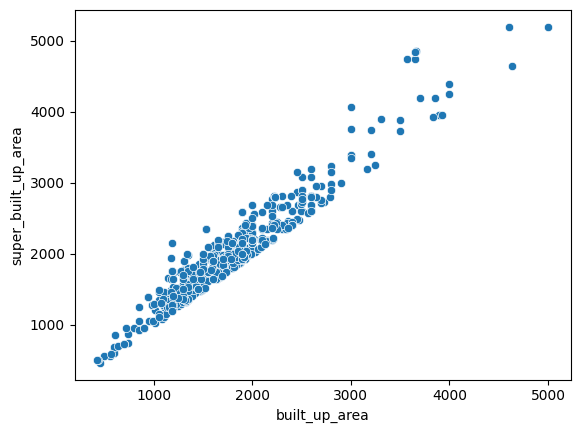

In [8]:
sns.scatterplot(x=df['built_up_area'],y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

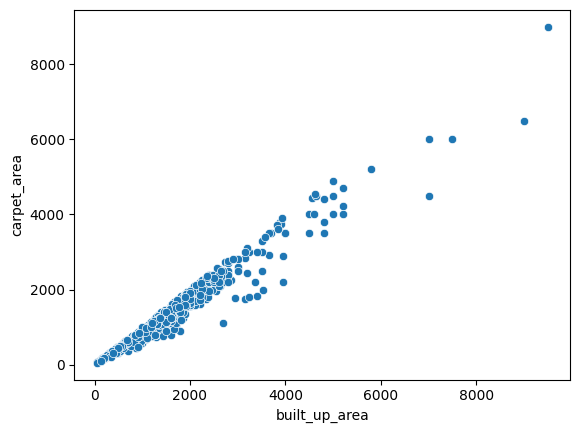

In [9]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [10]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

0       False
1       False
2       False
3       False
4       False
        ...  
3552    False
3553    False
3554    False
3555    False
3556    False
Length: 3557, dtype: bool

In [11]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [12]:
all_present_df.shape

(529, 25)

In [13]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [15]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [16]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.1051948051948053 0.900280112044818


In [17]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [18]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1,flat,dlf the primus,sector 82a,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet a...,4.0,4.0,3+,2.0,North-East,New Property,A north facing 4 bhk resale flat is available ...,2606.0,NaN,1800.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0,651.500000
7,flat,shree vardhman flora,sector 90,1.27,4951.0,2565.0,Super Built up area 2575(239.23 sq.m.)Carpet a...,4.0,5.0,2,9.0,North-East,New Property,This 4 bhk flat is located in shree vardhman f...,2575.0,NaN,1950.0,1.0,1.0,0.0,0.0,0.0,1.0,83.0,641.250000
10,flat,m3m woodshire,sector 107,1.29,8836.0,1460.0,Super Built up area 1943(180.51 sq.m.)Carpet a...,3.0,3.0,3+,1.0,East,Relatively New,Furnished apartment available 3 bhk spacious i...,1943.0,NaN,1460.0,0.0,0.0,0.0,1.0,0.0,0.0,174.0,486.666667
17,flat,signature global the millennia,sector 37d,0.65,10906.0,596.0,Super Built up area 650(60.39 sq.m.)Carpet are...,2.0,2.0,3,0.0,NaN,New Property,"Ground floor, parking facing \nAdjoining comme...",650.0,NaN,596.0,0.0,0.0,0.0,0.0,0.0,1.0,40.0,298.000000
26,flat,spaze privy,sector 72,3.10,6693.0,4632.0,Super Built up area 4632(430.33 sq.m.)Carpet a...,4.0,5.0,3+,8.0,South,Moderately Old,Sohna road sector 72 it park spr road . Nh8 an...,4632.0,NaN,2300.0,1.0,1.0,1.0,1.0,0.0,1.0,136.0,1158.000000


In [19]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_7520\1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_7520\1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
 

In [20]:
df.update(sbc_df)

In [21]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1012
agePossession             0
description               0
super_built_up_area    1688
built_up_area          1552
carpet_area            1712
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [22]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [23]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
6,flat,sobha city,sector 108,3.35,13267.0,2525.0,Super Built up area 2072.9(192.58 sq.m.),3.0,4.0,2,19.0,NaN,New Property,Sobha city gurgaon by sobha ltd.\nOver 86% of ...,2072.9,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,102.0,841.666667
11,flat,ats triumph,sector 104,1.73,7555.0,2290.0,Super Built up area 2290(212.75 sq.m.),3.0,4.0,3+,15.0,North-East,Relatively New,This 3 bhk apartment is available for sale in ...,2290.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,159.0,763.333333
13,flat,tulip violet,sector 69,1.43,9039.0,1582.0,Super Built up area 1578(146.6 sq.m.),3.0,3.0,2,1.0,North-East,Relatively New,Located in the popular residential address of ...,1578.0,NaN,NaN,0.0,0.0,0.0,1.0,0.0,1.0,102.0,527.333333
20,flat,smart world orchard,sector 61,2.24,14461.0,1549.0,Super Built up area 1549(143.91 sq.m.),3.0,3.0,2,3.0,NaN,New Property,Residential apartment for sell.Located in sect...,1549.0,NaN,NaN,0.0,0.0,0.0,0.0,1.0,1.0,61.0,516.333333
25,flat,sare crescent parc royal greens phase 1,sector 92,0.95,5008.0,1897.0,Super Built up area 1897(176.24 sq.m.),4.0,5.0,3+,4.0,NaN,Moderately Old,Attached bath spacious rooms. Big drawing dini...,1897.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,37.0,474.250000


In [24]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_7520\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_7520\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round(s

In [25]:
df.update(sb_df)

In [26]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1012
agePossession             0
description               0
super_built_up_area    1688
built_up_area           680
carpet_area            1712
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [27]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [28]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
5,flat,gls arawali homes,sohna road,0.28,5983.0,468.0,Carpet area: 468 (43.48 sq.m.),2.0,2.0,2,3.0,NaN,Relatively New,"Sun facing, moduler kitchen, newly constructed",NaN,NaN,468.0,0.0,0.0,0.0,0.0,0.0,1.0,42.0,234.0
14,house,independent,sector 12,6.00,35088.0,1710.0,Plot area 190(17.65 sq.m.)Carpet area: 1600 sq...,4.0,6.0,2,2.0,North-East,Old Property,"6 bath, semi-Furnished, north - East facing, 2...",NaN,NaN,1600.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,427.5
23,flat,pyramid urban homes 2,sector 86,0.50,9615.0,520.0,Carpet area: 520 (48.31 sq.m.),2.0,2.0,1,10.0,NaN,Relatively New,Location is good and is on main road,NaN,NaN,520.0,0.0,0.0,0.0,0.0,0.0,1.0,15.0,260.0
31,house,independent,sector 67,3.00,11905.0,2520.0,Carpet area: 2520 (234.12 sq.m.),4.0,4.0,0,3.0,North-East,Undefined,Beautiful house with ready to move option.All ...,NaN,NaN,2520.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,630.0
34,flat,signature global solera,sector 107,0.50,7752.0,645.0,Carpet area: 645 (59.92 sq.m.),3.0,2.0,2,6.0,South-East,Relatively New,This beautiful 3 bhk flat in sector 107 gurgao...,NaN,NaN,645.0,0.0,0.0,0.0,0.0,1.0,1.0,15.0,215.0


In [29]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_7520\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_7520\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet_a

In [30]:
df.update(c_df)

In [31]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1012
agePossession             0
description               0
super_built_up_area    1688
built_up_area             0
carpet_area            1712
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

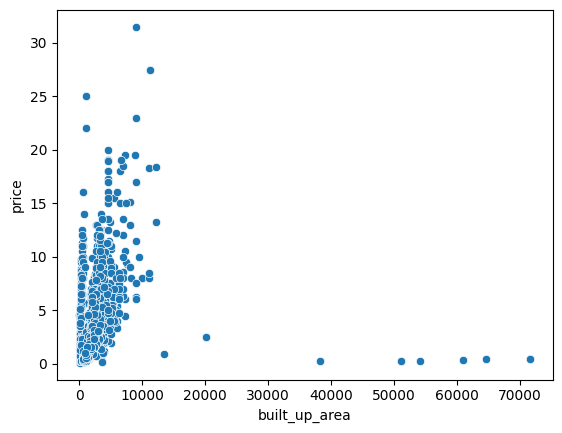

In [33]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [34]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [35]:
anamoly_df.sample(5)

,price,area,built_up_area
2506,6.40,2592.0,240.00
3031,2.64,2252.0,1750.75
562,3.40,2200.0,1991.00
3054,2.60,1711.0,1548.00
3386,5.30,1935.0,1935.00


In [36]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [37]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

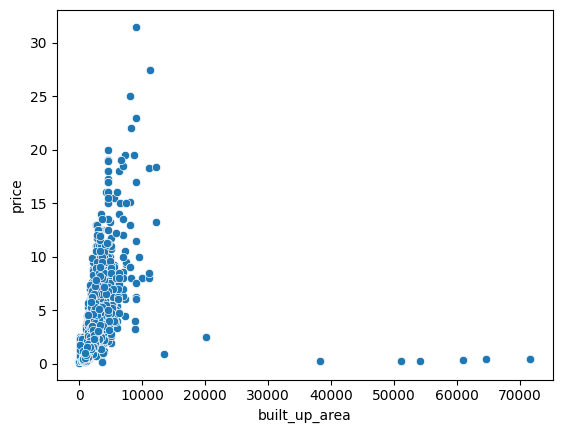

In [39]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [40]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [41]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,smart world orchard,sector 61,1.41,12250.0,2.0,2.0,2,2.0,NaN,Under Construction,Situated in prime location of sector 61 on gol...,1150.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0
1,flat,dlf the primus,sector 82a,2.85,10936.0,4.0,4.0,3+,2.0,North-East,New Property,A north facing 4 bhk resale flat is available ...,2179.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0
2,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,2.0,2.0,2,14.0,North-West,Undefined,"Club house, mini theater, squash court, swimmi...",915.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,house,independent,sector 7,1.20,11194.0,2.0,4.0,2,3.0,NaN,Undefined,5bhk residential house for resale in jyoti par...,1072.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,flat,hcbs sports ville,sohna road,0.27,4348.0,2.0,2.0,2,10.0,NaN,Relatively New,Raw flat as given by builder. Good location ne...,619.0,0.0,0.0,0.0,0.0,0.0,1.0,43.0


In [42]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1012
agePossession         0
description           0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### floorNum

In [43]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
58,house,vipul tatvam villa,sector 48,8.50,26235.0,4.0,4.0,1,NaN,NaN,Relatively New,360 sq yard 4 bhk residential villa for sale i...,3240.0,0.0,0.0,0.0,0.0,0.0,1.0,21.0
367,flat,NaN,sector 78,0.60,3692.0,2.0,2.0,0,NaN,NaN,Under Construction,The property is under construction it's by rah...,1625.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
439,house,emaar mgf marbella,sector 66,9.00,21251.0,4.0,4.0,3+,NaN,South-West,Relatively New,A lifestyle designed to satiate all your sense...,5200.0,0.0,1.0,1.0,1.0,0.0,0.0,114.0
731,house,independent,sector 4,4.12,8889.0,2.0,1.0,3+,NaN,NaN,Moderately Old,"Property next to dhanwapur underpass, which is...",4635.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
808,house,independent,sector 24,1.45,2984.0,3.0,3.0,1,NaN,NaN,Old Property,Interested to sell independent house/villa.Pla...,540.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0
959,house,ansal sushant lok plots,sector 43,3.30,26570.0,1.0,1.0,0,NaN,NaN,Under Construction,"Close proximity to gold souk , huda city centr...",1242.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1311,house,independent,sector 2,5.60,17284.0,8.0,6.0,3+,NaN,South-West,Moderately Old,360 sq. Yards plot area near by global foyer m...,3240.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0
1355,house,jacob pura,sector 12,0.35,9722.0,2.0,1.0,0,NaN,NaN,Old Property,Independece house for sale in jacobpura near k...,360.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1427,house,independent,sector 3,1.50,10288.0,3.0,3.0,0,NaN,NaN,Old Property,Ground floor and partial first floor built up,210.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1434,house,independent,sector 25,13.00,45710.0,6.0,8.0,3+,NaN,NaN,Relatively New,An impeccable opportunity is here for those wh...,2844.0,1.0,1.0,1.0,1.0,0.0,2.0,0.0


In [44]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [45]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_7520\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [46]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1012
agePossession         0
description           0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [47]:
1011/df.shape[0]

0.28422828226033175

### facing

<Axes: ylabel='count'>

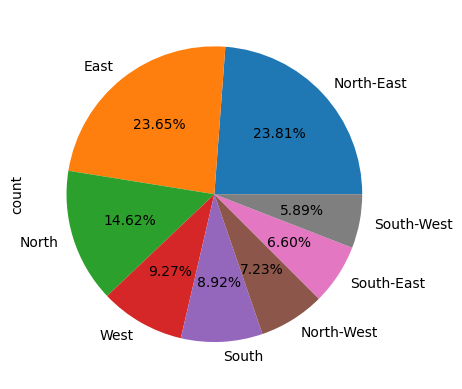

In [48]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [49]:
df.drop(columns=['facing'],inplace=True)

In [50]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1155,flat,corona optus,sector 37c,1.25,7176.0,3.0,3.0,3,2.0,Relatively New,This 3 bhk apartment is available for sale in ...,1563.0,1.0,0.0,0.0,0.0,0.0,1.0,49.0
804,flat,palam vihar society,sector 2,0.40,8602.0,1.0,1.0,1,5.0,Moderately Old,"One of the best locations with malls, schools,...",450.0,0.0,0.0,0.0,0.0,0.0,0.0,39.0
2446,flat,emaar mgf emerald floors premier,sector 65,2.65,16061.0,3.0,3.0,3,5.0,Relatively New,Emerald floors premier sector 65\nGated power ...,1650.0,1.0,1.0,0.0,0.0,0.0,1.0,37.0
1018,flat,godrej nature plus,sector 33,1.08,13123.0,2.0,2.0,3,8.0,Under Construction,"Full of amenities ,lush green gardens swimming...",85.0,0.0,0.0,0.0,0.0,0.0,1.0,56.0
1168,flat,ireo skyon,sector 60,3.70,13214.0,4.0,5.0,3,10.0,Relatively New,Ireo skyon is one of the most popular destinat...,2534.0,0.0,1.0,0.0,0.0,0.0,0.0,165.0


In [51]:
df.isnull().sum()


property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
description        0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [52]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
367,flat,NaN,sector 78,0.6,3692.0,2.0,2.0,0,2.0,Under Construction,The property is under construction it's by rah...,1625.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [53]:
df.drop(index=[367],inplace=True)

In [54]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
description        0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossession

In [55]:
df['agePossession'].value_counts()

agePossession
Relatively New        1609
New Property           556
Moderately Old         543
Old Property           293
Undefined              291
Under Construction     264
Name: count, dtype: int64

In [56]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,2.0,2.0,2,14.0,Undefined,"Club house, mini theater, squash court, swimmi...",915.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,house,independent,sector 7,1.20,11194.0,2.0,4.0,2,3.0,Undefined,5bhk residential house for resale in jyoti par...,1072.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12,flat,lig flat,sector 40,1.50,5556.0,1.0,1.0,0,0.0,Undefined,Looking for a 1 bhk apartment for sale in gurg...,300.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15,house,surendra homes dayaindependentd colony,sector 6,0.75,15625.0,4.0,4.0,2,1.0,Undefined,Looking for a 4 bhk independent house for sale...,480.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31,house,independent,sector 67,3.00,11905.0,4.0,4.0,0,3.0,Undefined,Beautiful house with ready to move option.All ...,2800.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3518,house,independent,sector 92,1.80,7627.0,4.0,5.0,0,13.0,Undefined,Best in class property available at sector 92 ...,2360.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3526,flat,dnha cghs,sector 1,0.85,3864.0,3.0,3.0,0,5.0,Undefined,Best in class property available at sector 1 l...,2200.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3530,house,satya the hermitage,sector 103,3.15,6702.0,4.0,5.0,0,12.0,Undefined,4bhk penthouse for resale in satya the hermita...,4700.0,0.0,0.0,0.0,0.0,0.0,1.0,61.0
3533,flat,sidhartha ncr one,sector 95,0.57,4179.0,2.0,2.0,2,10.0,Undefined,"2 bath, semi-Furnished, 10th floor (Of 17), at...",1364.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [57]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [58]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [59]:
df['agePossession'].value_counts()

agePossession
Relatively New        1732
New Property           584
Moderately Old         582
Old Property           326
Under Construction     278
Undefined               54
Name: count, dtype: int64

In [60]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [61]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [62]:
df['agePossession'].value_counts()

agePossession
Relatively New        1742
Moderately Old         589
New Property           585
Old Property           329
Under Construction     278
Undefined               33
Name: count, dtype: int64

In [63]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [64]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [65]:
df['agePossession'].value_counts()

agePossession
Relatively New        1744
Moderately Old         620
New Property           585
Old Property           329
Under Construction     278
Name: count, dtype: int64

In [66]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
description        0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [67]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [68]:
df.shape

(3556, 19)